# Week4 - Homework 1

### Complete _todo_ parts in the following:

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [139]:
def create_df():
    df = pd.DataFrame()
    n = 10000
    x = np.linspace(0, 2*np.pi, n)
    y = 2*np.cosh(x/2) + np.random.normal(0, 3, n)

    x2 = random.choices(['A', 'B'], k=n)

    df['X1'] = x
    df['X2'] = x2
    df['y'] = [ y + 5 if b == 'A' else  y for y, b in zip(y, x2)]
    return df

df = create_df()

In [140]:
df.head()

,X1,X2,y
0,0.000000,B,5.005145
1,0.000628,A,14.206909
2,0.001257,A,4.975433
3,0.001885,A,10.413889
4,0.002514,B,-2.025135


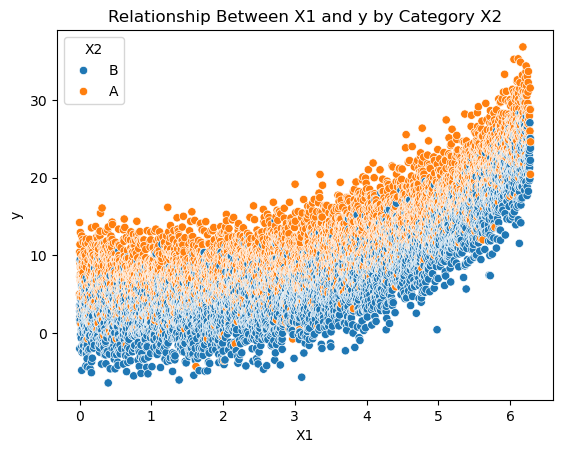

In [141]:
# todo: add a proper title
sns.scatterplot(data=df, x='X1', y='y', hue='X2')
plt.title("Relationship Between X1 and y by Category X2")
plt.xlabel("X1")
plt.ylabel("y")
plt.show()

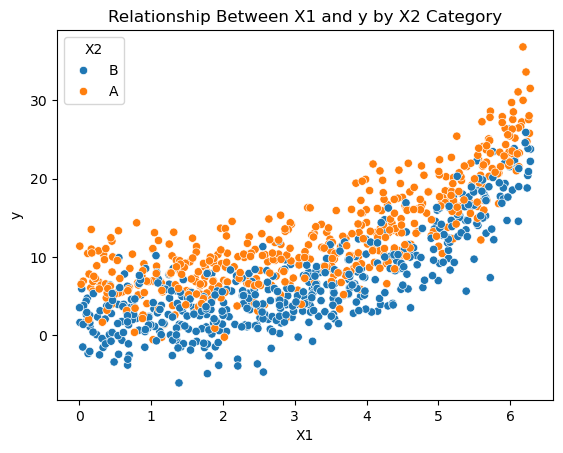

In [142]:
# todo: add the same title as above
sns.scatterplot(data=df.sample(1000), x='X1', y='y', hue='X2')
plt.title("Relationship Between X1 and y by X2 Category")
plt.xlabel("X1")
plt.ylabel("y")
plt.show()


#### Todo: 
explain findings in the graphs

the graphs show a clear positive relationship between X1 and y with y increasing as X1 increases the pattern shows a slight curve which indicates that there might be a nonlinear relationship between the two variables. The analysis shows that category a consistently produces higher y values than category B which demonstrates that X2 has an effect on the response variable the sampled data shows the same overall pattern that exists in the complete dataset

In [143]:
X = df[['X1', 'X2']]
y = df.y

In [144]:
X.head()

,X1,X2
0,0.000000,B
1,0.000628,A
2,0.001257,A
3,0.001885,A
4,0.002514,B


In [145]:
model = LinearRegression()
model.fit(X[['X1']], y)

model.score(X[['X1']], y) 

0.5790209398857113

In [146]:
y_pred = model.predict(X[['X1']])
r2_score( y, y_pred)

0.5790209398857113

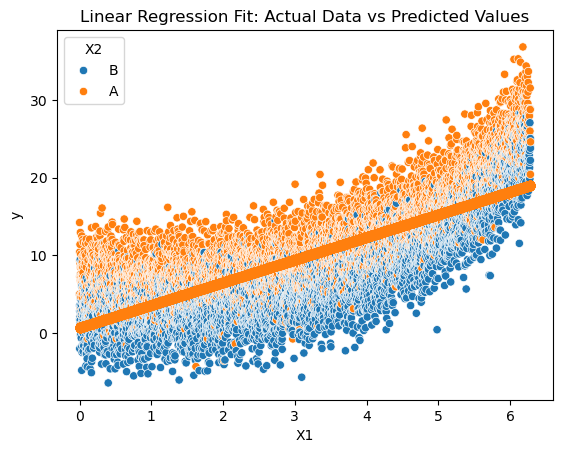

In [147]:
# todo: add a proper title
sns.scatterplot(data=df, x='X1', y='y', hue='X2') 
plt.scatter(X.X1, y_pred)
plt.title("Linear Regression Fit: Actual Data vs Predicted Values")
plt.xlabel("X1")
plt.ylabel("y")
plt.show()

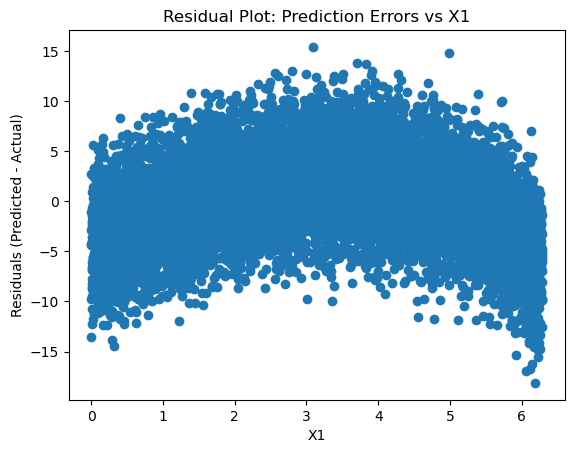

In [148]:
# todo: add a proper title
plt.scatter(X.X1, y_pred-y)
plt.title("Residual Plot: Prediction Errors vs X1")
plt.xlabel("X1")
plt.ylabel("Residuals (Predicted - Actual)")
plt.show()

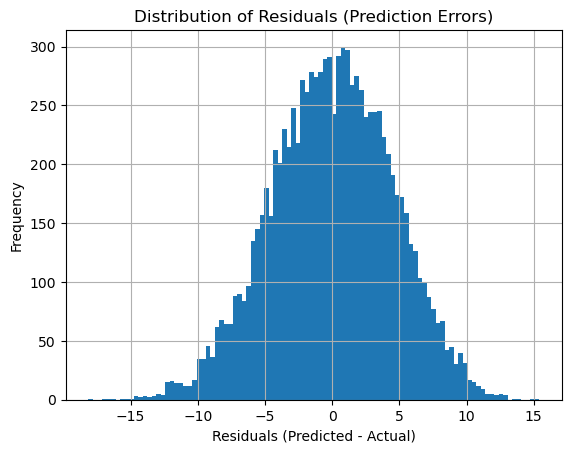

In [149]:
# todo: add a proper title
(y_pred-y).hist(bins=100)
plt.title("Distribution of Residuals (Prediction Errors)")
plt.xlabel("Residuals (Predicted - Actual)")
plt.ylabel("Frequency")
plt.show()

#### Todo: 
Explain findings in the graphs above & what we can try next

the relationship between X1 and y it shows a positive trend which is followed with  a curved pattern so a simple linear model fails to describe the relationship the residual plot confirms thta  as it showing a curved structure instead of random scatter the R2 value of 0.577 shows that the model accounts for 57.7% of y variation which indicates medium model performance 

the model requires a polynomial term because X1 and y show a non-linear relationship the model should include X2 as an extra predictor instead of treating it as an unneeded variable the changes to the model will enhance its R2value while improving its fit to the data

In [150]:
# todo: explain the code below, what we do & why we do it? 
#We use polynomial regression as our method to enhance model performance the code uses PolynomialFeatures(degree=2) 
#to create an extra feature X1(2) which enables the model to detect nonlinear relationships the fit_transform() 
#function generates a new feature matrix containing both X1 and X1(2) we fit a linear regression model to this data after transforming it. 
#We maintain our use of LinearRegression() while its function changes into polynomial regression after we train it on polynomial features

transform = PolynomialFeatures(degree=2)

X_data = transform.fit_transform(X[['X1']])

model = LinearRegression()
model.fit(X_data, y)

model.score(X_data, y) 

0.6849678899815683

In [151]:
y_pred = model.predict(X_data)
r2_score(y, y_pred)

0.6849678899815683

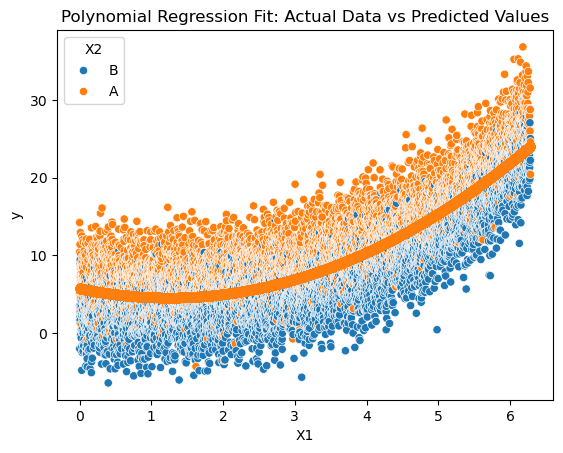

In [152]:
# todo: add a proper title
sns.scatterplot(data=df, x='X1', y='y', hue='X2') 
plt.scatter(X.X1, y_pred)
plt.title("Polynomial Regression Fit: Actual Data vs Predicted Values")
plt.xlabel("X1")
plt.ylabel("y")
plt.show()

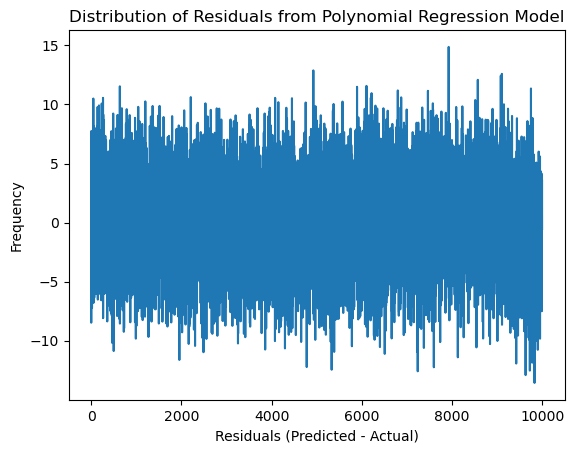

In [153]:
# todo: add a proper title
(y_pred-y).plot()
plt.title("Distribution of Residuals from Polynomial Regression Model")
plt.xlabel("Residuals (Predicted - Actual)")
plt.ylabel("Frequency")
plt.show()

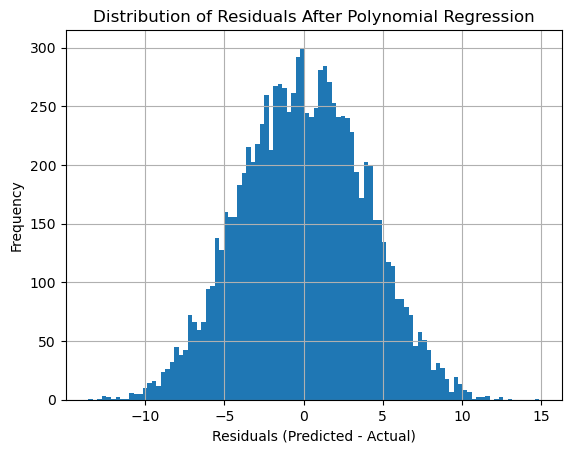

In [154]:
# todo: add a proper title
(y_pred-y).hist(bins=100)
plt.title("Distribution of Residuals After Polynomial Regression")
plt.xlabel("Residuals (Predicted - Actual)")
plt.ylabel("Frequency")
plt.show()

### Todo:
Explain findings in the above graphs & what can we do next? 

the original scatterplot showed a positive relationship between X1 and y which followed a curved path which proved that a basic linear model could not adequately describe the data the linear regression model has failed to represent the complete curvature of the data which resulted in a residual plot that displayed systematic patterns instead of random distribution showing  a problem with model specification the linear model achieved an R2 value of 0.577, which demonstrated that it could account for 57.7% of the variations observed in y.

The regression curve now closely matches the scatterplot's actual curvature after we implemented polynomial regression the residuals now show a distribution that centralizes more with fewer organized patterns in comparison to the linear model the R2 value improved to 0.678, which demonstrates that the model now accounts for 67.8% of the changes in y, showing significant advancemen 

As a next step we could compare the polynomial regression model with a simple linear regression model to see if the polynomial terms truly improve performance evaluateing multiple polynomial degrees to measure their effect on model accuracy and overfitting tendencies the model evaluation process will use train-test split results to verify its performance on previously unseen data 

##  Finally:

In [155]:
## to see the difference (leave these blocks commented when submitting)
# encoder = OneHotEncoder()

# categorical_features = ['X2']
# encoded = encoder.fit_transform(X[categorical_features])

# pd.DataFrame(
#     data=encoded.todense(), 
#     columns=encoder.get_feature_names_out()
# ).head()

In [156]:
encoder = OneHotEncoder(drop='first')

categorical_features = ['X2']
encoded = encoder.fit_transform(X[categorical_features])

In [157]:
encoded_df = pd.DataFrame(
    data=encoded.todense(), 
    columns=encoder.get_feature_names_out()
)

In [158]:
encoded_df.head()

,X2_B
0,1.0
1,0.0
2,0.0
3,0.0
4,1.0


In [159]:
# todo: explain the code
#the code selects the numerical feature X1 and combines it with the encoded 
#categorical variables to create a new dataset  which includes all predictor variables. 
#The head() function is used to preview the merged data.
numerical_features = ['X1']
X_new = X[numerical_features].join(encoded_df)
X_new.head()

,X1,X2_B
0,0.000000,1.0
1,0.000628,0.0
2,0.001257,0.0
3,0.001885,0.0
4,0.002514,1.0


In [160]:
# todo: explain the code
#EXPLANATION-This code uses polynomial features to create additional polynomial and interaction from the input variables
#enables the model to capture more complex relationships. The transformed data is used to train a LinearRegression model. 
#The R² score is calculated to assess the model's ability to explain the variation in the target variable.
poly = PolynomialFeatures()
X_data = poly.fit_transform(X_new)

model = LinearRegression()
model.fit(X_data, y)

model.score(X_data, y) 

0.8094785601353172

In [161]:
y_pred = model.predict(X_data)
r2_score(y, y_pred)

0.8094785601353172

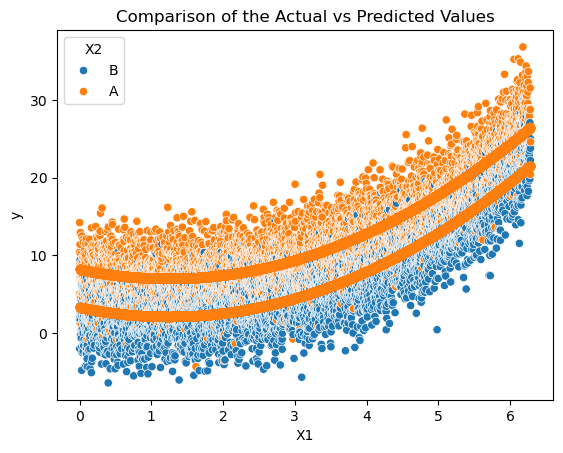

In [162]:
# if you want to see the difference between the below plot,
#  uncomment the next 2 lines & comment the other lines.
#  (leave these commented when submitting)
# plt.scatter(X_new.X1, y)
# plt.scatter(X_new.X1, y_pred)

# todo: add a proper title

sns.scatterplot(data=df, x='X1', y='y', hue='X2') 
plt.scatter(X_new.X1, y_pred)
plt.title("Comparison of the Actual vs Predicted Values")
plt.xlabel("X1")
plt.ylabel("y")
plt.show()

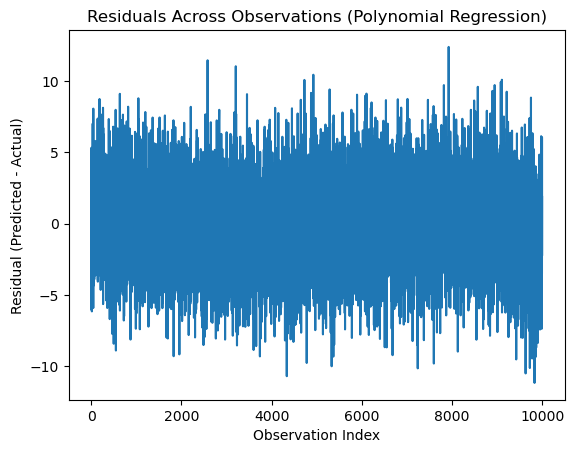

In [163]:
# todo: add a proper title

(y_pred - y).plot()
plt.title("Residuals Across Observations (Polynomial Regression)")
plt.xlabel("Observation Index")
plt.ylabel("Residual (Predicted - Actual)")
plt.show()

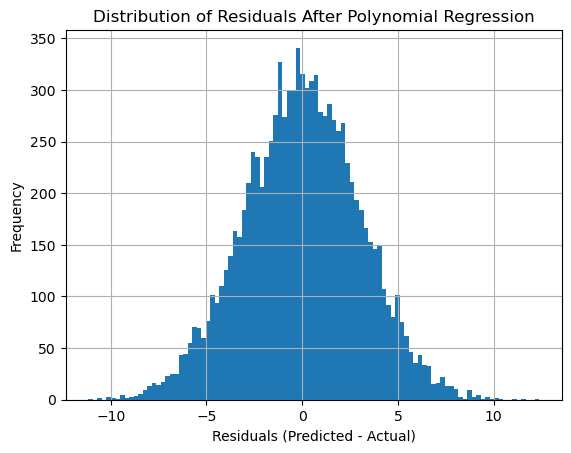

In [164]:
# todo: add a proper title
(y_pred-y).hist(bins=100)
plt.title("Distribution of Residuals After Polynomial Regression")
plt.xlabel("Residuals (Predicted - Actual)")
plt.ylabel("Frequency")
plt.show()

#### Todo: 
explain results

the polynomial regression model gives a better fit to the data than the simple linear regression model the R2 value increased  which shows  that the model is responsible for additional variation in the target variable

the residual plot shows random error distribution because the errors distribute evenly across the zero line, which indicates that all systematic patterns in the data have been eliminated the model demonstrates no prediction bias because the residuals show an approximately symmetric distribution that centers around zero

the polynomial model demonstrates better performance than the linear model because it effectively captures the nonlinear data relationship

## Create a train-test split

In [165]:
X_training, X_test, y_training, y_test = train_test_split(X, y)

print(f'Training samples: {X_training.shape[0]:,}')
print(f'Test samples: {X_test.shape[0]:,}')

Training samples: 7,500
Test samples: 2,500


 ## Train a linear regression model
  
 * Perform the model training on training set, follow the steps after `Finally` on the training set. 
 * Get the r2_score on the test set.
 
 Important note: When transforming use `fit_transform` on the training set and use `transform` on the test set.
 
 __eg:__
 
 `encoded_training = encoder.fit_transform(X_train[categorical_features])`
 
 `encoded_testing = encoder.transform(X_test[categorical_features])`
     

In [166]:
X_training.head()

,X1,X2
313,0.196683,B
234,0.147041,A
5774,3.628274,B
7317,4.597866,B
443,0.278373,A


In [167]:
# code
# X_training2 = X_training.copy()

# X_training2['isB'] = [ 1 if x == 'B' else 0  for x in X_training['X2']]
# X_training2.drop('X2', axis = 1, inplace=True)
# X_training2.head()

encoder= OneHotEncoder(drop='first')
X_trainingEncoded = encoder.fit_transform(X_training[['X2']])


X_training2 = pd.DataFrame({
    'X1': X_training.X1,
    'X2': X_trainingEncoded.toarray()[:, 0]
})
X_training2.head()


,X1,X2
313,0.196683,1.0
234,0.147041,0.0
5774,3.628274,1.0
7317,4.597866,1.0
443,0.278373,0.0


In [168]:
m = LinearRegression().fit(X_training2, y_training)

X_testEncoded = encoder.transform(X_test[['X2']])
X_test2 = pd.DataFrame({
    'X1': X_test.X1,
    'X2': X_testEncoded.toarray()[:, 0]
})
m.score(X_test2, y_test)

0.7011955275518733

## Create a pipeline

Add comments to `todo` parts

In [169]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression

cat_vars = ['X2']
num_vars = ['X1']
# Applying polynomial features to numerical variable to capture non-linear patterns
num_pipeline = Pipeline([
    ('polynomial_features', PolynomialFeatures(degree=2))
])
# Converting categorical variable into dummy variables
cat_pipeline = Pipeline([
    ('create_dummies_cats', OneHotEncoder(handle_unknown='ignore', drop='first'))
])
# Applying the correct transformation to each column type
processing_pipeline = ColumnTransformer(transformers=[
    ('num pipeline', num_pipeline, num_vars),
    ('cat pipeline', cat_pipeline, cat_vars)
])
modeling_pipeline = Pipeline([
    ('data_processing', processing_pipeline), 
    ('lm', LinearRegression())
])

print(modeling_pipeline)

Pipeline(steps=[('data_processing',
                 ColumnTransformer(transformers=[('num pipeline',
                                                  Pipeline(steps=[('polynomial_features',
                                                                   PolynomialFeatures())]),
                                                  ['X1']),
                                                 ('cat pipeline',
                                                  Pipeline(steps=[('create_dummies_cats',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['X2'])])),
                ('lm', LinearRegression())])


In [170]:
modeling_pipeline.fit(X_training, y_training)

Pipeline(steps=[('data_processing',
                 ColumnTransformer(transformers=[('num pipeline',
                                                  Pipeline(steps=[('polynomial_features',
                                                                   PolynomialFeatures())]),
                                                  ['X1']),
                                                 ('cat pipeline',
                                                  Pipeline(steps=[('create_dummies_cats',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['X2'])])),
                ('lm', LinearRegression())])

In [171]:
modeling_pipeline.score(X_test, y_test)

0.8055908994213844

## Evaluate/create residual plots

In [172]:
y_pred = modeling_pipeline.predict(X_test)

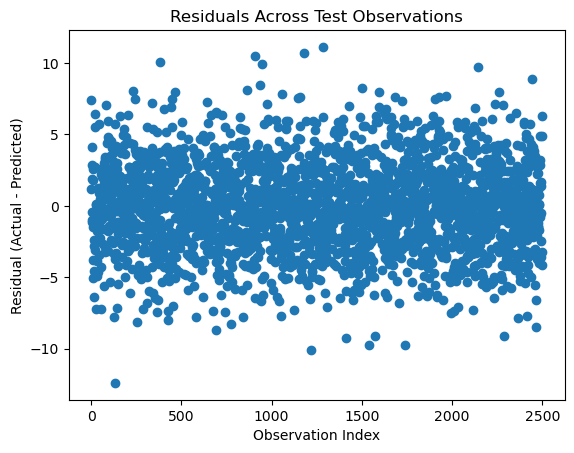

In [173]:
y_pred = modeling_pipeline.predict(X_test)

residuals = y_test - y_pred

# Residual scatter plot
plt.figure()
plt.scatter(range(len(residuals)), residuals)
plt.title("Residuals Across Test Observations")
plt.xlabel("Observation Index")
plt.ylabel("Residual (Actual - Predicted)")
plt.show()


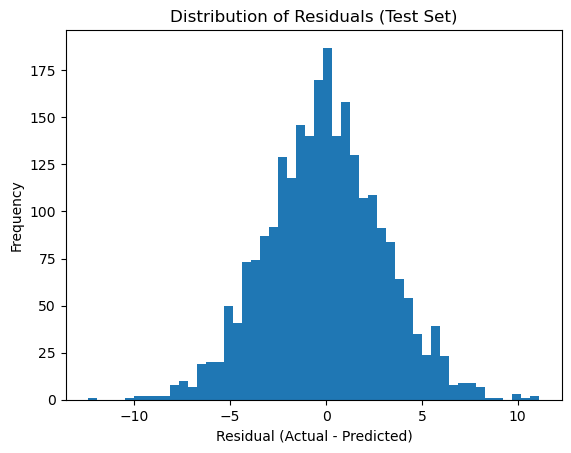

In [174]:
#Residual histogram
plt.figure()

plt.hist(residuals, bins=50)
plt.title("Distribution of Residuals (Test Set)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()

## Explain findings

Explain findings

the residual scatter plot displays random error distribution which fails to reveal any remaining systematic patterns in the data the model shows good performance because it successfully captures the relationship between the predictors and the targeted variable 

the model shows no strong predictive bias because its residual histogram displays symmetrical distribution which centers at zero the residual plots shows that the modeling pipeline successfully transfers its results to test data while maintaining accurate model performance